# This notebook will serve to explore Cary's Food Waste Recycling API

In [1]:
# import relevant libraries
import requests
import pandas as pd
import seaborn as sns
import plotly.express as px

In [2]:
# Base URL for Cary's Food Waste Recycling Data
cary_base_url = 'https://data.townofcary.org/api/explore/v2.1/catalog/datasets/food-waste-pilot'

# We have two endpoints, but we're going to focus on using the 'exports' endpoint to evaluate the entire dataset
records_endpoint = '/records'
json_exports_endpoint = '/exports/json'

# We store our response from the API in a variable and we store it as json
response = requests.get(cary_base_url + json_exports_endpoint)
json_data = response.json()

In [3]:
type(json_data[0])

dict

In [4]:
df = pd.DataFrame(json_data)

In [5]:
df.head()

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs
0,Citizen's Convenience Center,2022-02-18,202.8,20.0
1,Citizen's Convenience Center,2022-02-25,250.8,25.0
2,Citizen's Convenience Center,2022-02-28,213.8,21.0
3,Citizen's Convenience Center,2022-03-21,601.2,60.0
4,Citizen's Convenience Center,2022-03-30,610.8,61.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   stop_name                 956 non-null    str    
 1   date_collection_datetime  956 non-null    str    
 2   lbs_collected             956 non-null    float64
 3   compost_created_lbs       956 non-null    float64
dtypes: float64(2), str(2)
memory usage: 30.0 KB


In [7]:
df.describe()

,lbs_collected,compost_created_lbs
count,956.000000,956.000000
mean,642.399059,64.209205
std,308.156512,30.815379
min,0.000000,0.000000
25%,449.750000,45.000000
50%,599.600000,60.000000
75%,763.075000,76.000000
max,2057.000000,206.000000


## Splitting date column to indicate year and month of the record.

The Descriptive statistics generated above make no sense given that entries make the most contextual sense when they're grouped by month, year, or quarter. Below I will plot a histogram of the overall dataset, then will attempt to plot histograms for the data grouped by year first.

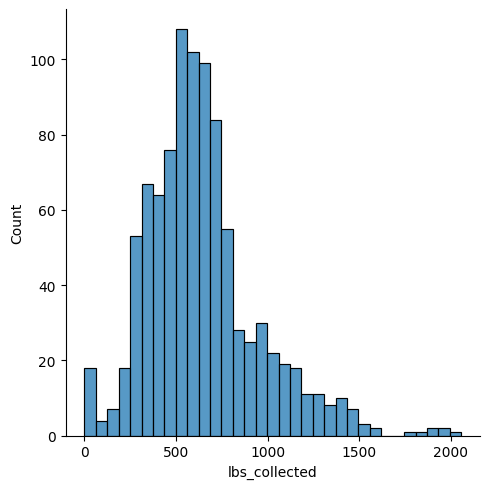

In [8]:
sns.displot(df['lbs_collected'])

In [9]:
#convert date_collection_datetime to datetime type
df['date_collection_datetime'] = pd.to_datetime(df['date_collection_datetime'])

In [10]:
# create a 'year' variable
df['year'] = df['date_collection_datetime'].dt.year

In [11]:
df.head()

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs,year
0,Citizen's Convenience Center,2022-02-18,202.8,20.0,2022
1,Citizen's Convenience Center,2022-02-25,250.8,25.0,2022
2,Citizen's Convenience Center,2022-02-28,213.8,21.0,2022
3,Citizen's Convenience Center,2022-03-21,601.2,60.0,2022
4,Citizen's Convenience Center,2022-03-30,610.8,61.0,2022


In [12]:
#subset data frame to only include pounds collected and year of collection
df_lbs_year = df[['lbs_collected', 'year']]
df_sum_lbs_year = df_lbs_year.groupby(["year"]).sum()

<Axes: xlabel='year', ylabel='lbs_collected'>

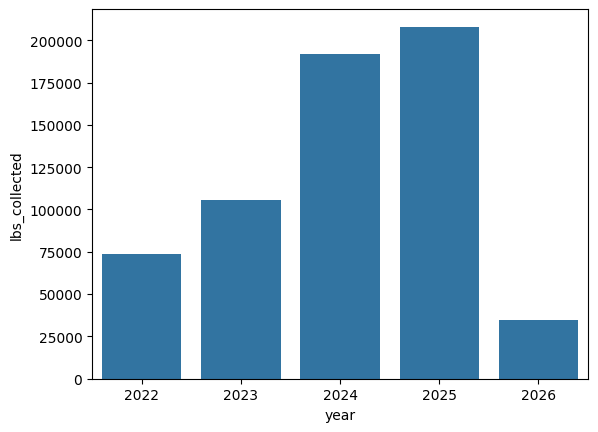

In [13]:
#generate bar plot of lbs collected by year
sns.barplot(x="year", y="lbs_collected", data=df_sum_lbs_year)

At first glance above, it seems like the Cary Composts program has resulted in a consistent increase in pounds collected over time. 2026 only looks low because there's only for the month of January.

Next, I want to dive in to take a look at the following:
- Histogram by year of collection
- boxplot grouped by both year of collection and collection site
- Lineplot of the entire dataset

## Histograms by year of collection

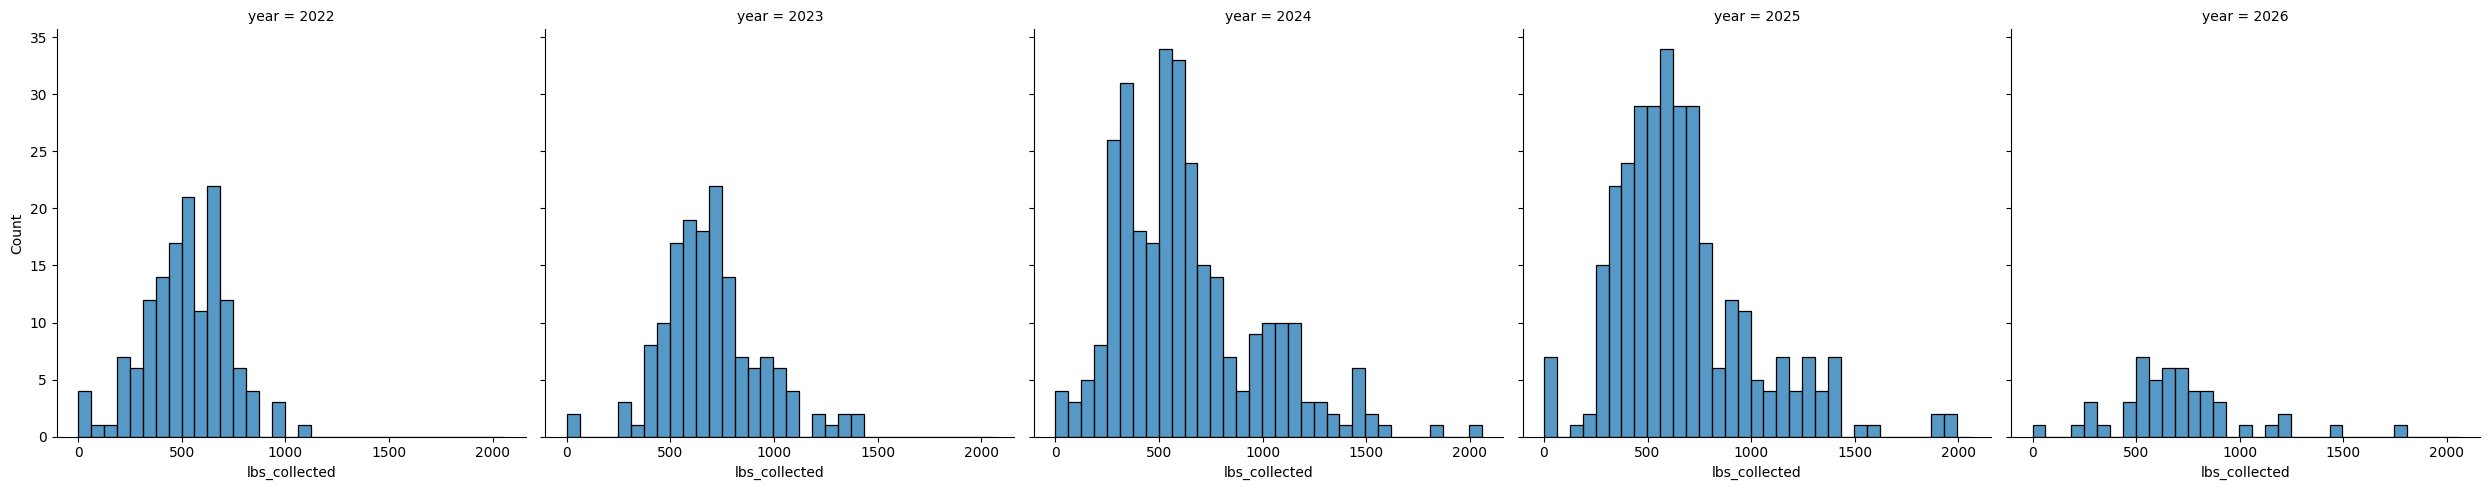

In [14]:
sns.displot(df, x='lbs_collected', col='year')

## Boxplot grouped by year and collection site

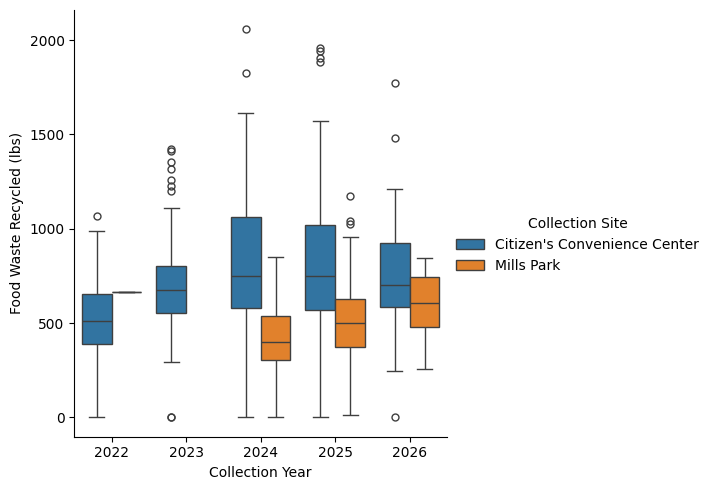

In [15]:
cat_plot_by_year_stop = sns.catplot(df, kind='box', x='year', y='lbs_collected', hue='stop_name')
cat_plot_by_year_stop.set_axis_labels('Collection Year', 'Food Waste Recycled (lbs)')
cat_plot_by_year_stop.legend.set_title("Collection Site")

<Axes: xlabel='year', ylabel='lbs_collected'>

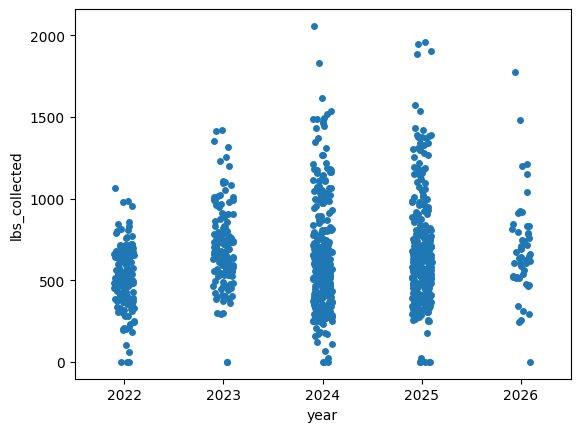

In [16]:
sns.stripplot(df, x='year', y='lbs_collected')

<Axes: ylabel='lbs_collected'>

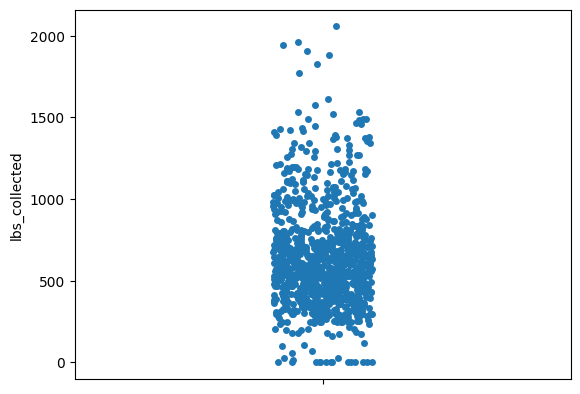

In [17]:
sns.stripplot(df['lbs_collected'])

<Axes: xlabel='date_collection_datetime', ylabel='lbs_collected'>

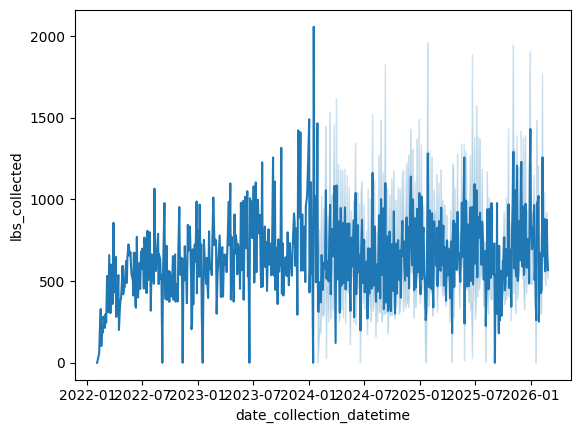

In [18]:
sns.lineplot(df, x="date_collection_datetime", y="lbs_collected")

In [19]:
df.loc[df['stop_name']=='Mills Park'].sort_values(by=["year"])

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs,year
329,Mills Park,2022-08-25,664.8,66.0,2022
40,Mills Park,2024-01-31,0.0,0.0,2024
45,Mills Park,2024-02-23,449.8,45.0,2024
44,Mills Park,2024-02-19,282.8,28.0,2024
50,Mills Park,2024-08-07,527.8,53.0,2024
...,...,...,...,...,...
139,Mills Park,2026-02-11,604.0,60.0,2026
138,Mills Park,2026-02-03,524.0,52.0,2026
135,Mills Park,2026-01-27,846.9,85.0,2026
134,Mills Park,2026-01-23,739.1,74.0,2026


Through the above table and by looking at the grouped boxplot, I've realized that there is one record in 2022 that's not accurate. There's a collection at Mills Park in 2022, which is an error because Mills Park didn't start participating in the Cary Composts program until 2024, as stated in their data story. It would be good to let the Cary people know of this.

### Trying to chart with plotly just in case it's more helpful.

While seaborn can get the job done, I want to try using plotly to make my line chart, in case it feeds off of the D3 power enough to scale the x-axis `date_collection_datetime` variable in a way that makes sense.

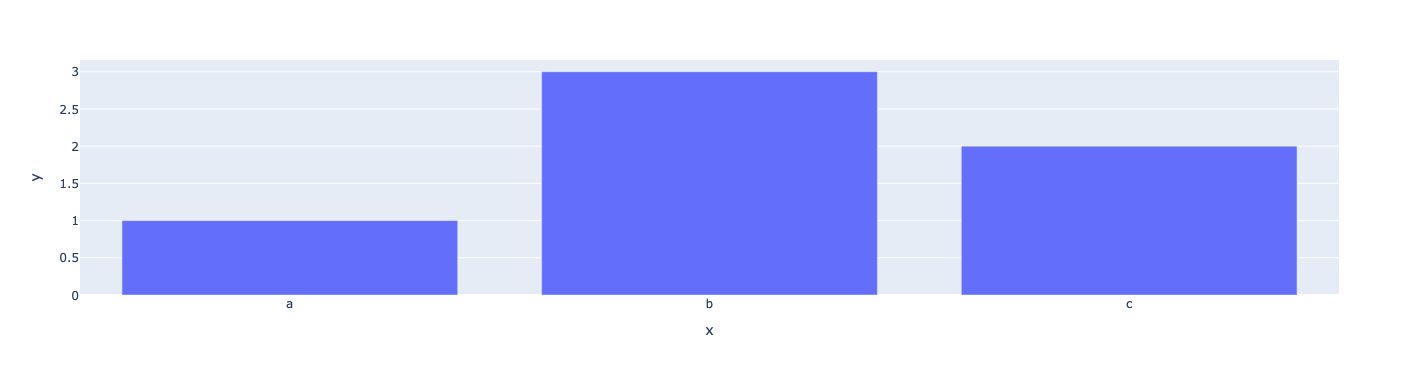

In [20]:
# The following is one of plotly's sample bar charts as a way to quickly show it working
fig = px.bar(x=["a", "b", "c"], y=[1, 3, 2])
fig.show()

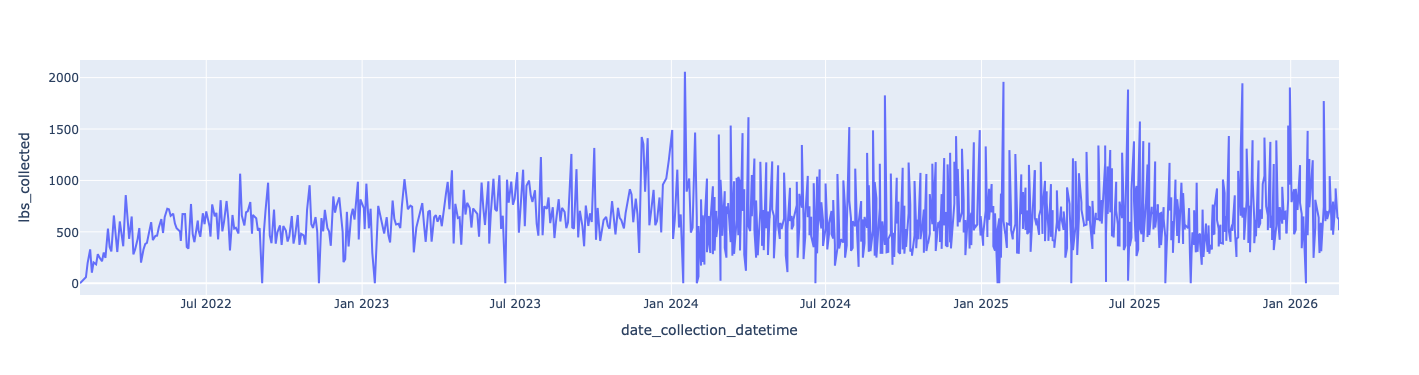

In [21]:
#sort by date first:
df = df.sort_values(by='date_collection_datetime')
df_lineplot = px.line(df, x='date_collection_datetime', y='lbs_collected')
df_lineplot.show()

Exploring the line chart above revealed an important nature of the data, which is that after Mills Park was added, there can be multiple collections in the same day. This makes the data have completely straight vertical lines in the chart. To get a better representation of the daily fluctuation in food waste recycling, I should be adding all collections at the day level, and then rechart to notice the difference. However, before doing so, I should remove the erroneous collection record for Mills Park in 2022. It's clearly throwing the chart off as shown below, when we add lines for each stop name:



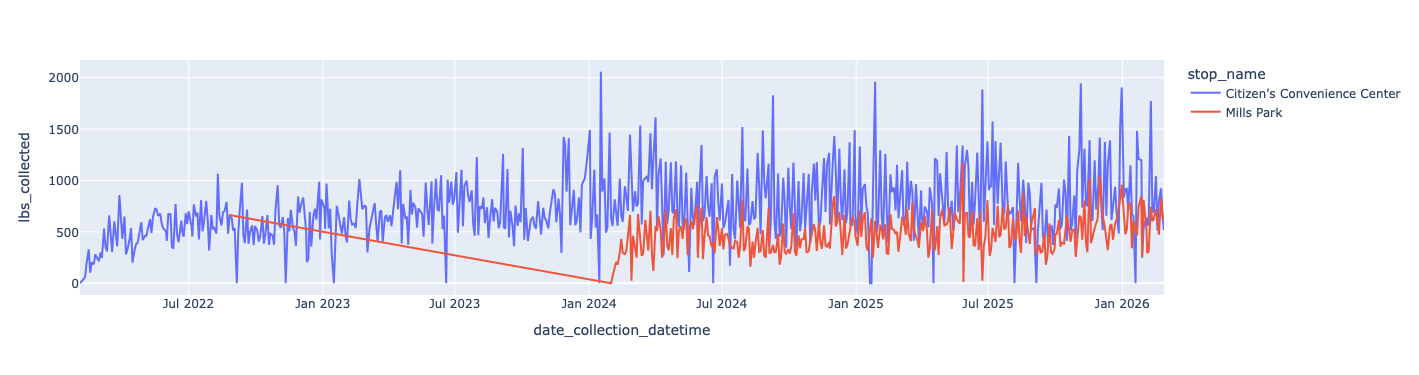

In [22]:
df_lineplot_by_stop = px.line(df, x='date_collection_datetime', y='lbs_collected', color='stop_name')
df_lineplot_by_stop.show()

In [23]:
conditions_to_remove = (df['stop_name'] == 'Mills Park') & (df['year'] == 2022)
df_cleaner = df[~conditions_to_remove]
print('df_cleaner dataframe length is: ' + str(len(df_cleaner)) + ' while df dataframe length is: ' + str(len(df)))

df_cleaner dataframe length is: 955 while df dataframe length is: 956


In [37]:
# Add fiscal_year column based on NC fiscal year (July 1 - June 30)
# FY 21-22: July 1, 2021 - June 30, 2022
# FY 22-23: July 1, 2022 - June 30, 2023
# FY 23-24: July 1, 2023 - June 30, 2024
# FY 24-25: July 1, 2024 - June 30, 2025

def get_fiscal_year(date):
    """Returns fiscal year string (e.g., '22-23') based on date."""
    year = date.year
    month = date.month
    if month >= 7:  # July-December: FY starts this calendar year
        fy_start = year
    else:  # January-June: FY started previous calendar year
        fy_start = year - 1
    fy_end = fy_start + 1
    return f"{str(fy_start)[-2:]}-{str(fy_end)[-2:]}"

df_cleaner['fiscal_year'] = df_cleaner['date_collection_datetime'].apply(get_fiscal_year)
print("Fiscal year distribution:")
print(df_cleaner['fiscal_year'].value_counts().sort_index())

Fiscal year distribution:
fiscal_year
21-22     62
22-23    153
23-24    219
24-25    312
25-26    209
Name: count, dtype: int64


In [44]:
# Convert pounds to tons (2000 lbs = 1 ton)
def calculateTonsFoodWaste(lbs):
    """Converts pounds to tons."""
    return lbs / 2000

df_cleaner['tons_collected'] = df_cleaner['lbs_collected'].apply(calculateTonsFoodWaste)
print(f"Total tons collected: {df_cleaner['tons_collected'].sum():.2f}")
print(f"\nTons collected by fiscal year:")
print(df_cleaner.groupby('fiscal_year')['tons_collected'].sum().sort_index())

Total tons collected: 306.73

Tons collected by fiscal year:
fiscal_year
21-22     13.97020
22-23     47.14130
23-24     74.23335
24-25    100.56190
25-26     70.82760
Name: tons_collected, dtype: float64


In [46]:
# Determine season based on astronomical season dates
from datetime import date

# Define season date ranges for each year (start_date, end_date, season)
season_ranges = [
    # Winter 2021-2022
    (date(2021, 12, 21), date(2022, 3, 19), 'Winter'),
    # Spring 2022
    (date(2022, 3, 20), date(2022, 6, 20), 'Spring'),
    # Summer 2022
    (date(2022, 6, 21), date(2022, 9, 21), 'Summer'),
    # Fall 2022
    (date(2022, 9, 22), date(2022, 12, 20), 'Fall'),
    # Winter 2022-2023
    (date(2022, 12, 21), date(2023, 3, 19), 'Winter'),
    # Spring 2023
    (date(2023, 3, 20), date(2023, 6, 20), 'Spring'),
    # Summer 2023
    (date(2023, 6, 21), date(2023, 9, 22), 'Summer'),
    # Fall 2023
    (date(2023, 9, 23), date(2023, 12, 20), 'Fall'),
    # Winter 2023-2024
    (date(2023, 12, 21), date(2024, 3, 18), 'Winter'),
    # Spring 2024
    (date(2024, 3, 19), date(2024, 6, 19), 'Spring'),
    # Summer 2024
    (date(2024, 6, 20), date(2024, 9, 21), 'Summer'),
    # Fall 2024
    (date(2024, 9, 22), date(2024, 12, 20), 'Fall'),
    # Winter 2024-2025
    (date(2024, 12, 21), date(2025, 3, 19), 'Winter'),
    # Spring 2025
    (date(2025, 3, 20), date(2025, 6, 19), 'Spring'),
    # Summer 2025
    (date(2025, 6, 20), date(2025, 9, 21), 'Summer'),
    # Fall 2025
    (date(2025, 9, 22), date(2025, 12, 20), 'Fall'),
    # Winter 2025-2026
    (date(2025, 12, 21), date(2026, 3, 19), 'Winter'),
    # Spring 2026
    (date(2026, 3, 20), date(2026, 6, 20), 'Spring'),
    # Summer 2026
    (date(2026, 6, 21), date(2026, 9, 21), 'Summer'),
    # Fall 2026
    (date(2026, 9, 22), date(2026, 12, 20), 'Fall'),
    # Winter 2026-2027
    (date(2026, 12, 21), date(2027, 3, 19), 'Winter'),
]

def determineSeason(dt):
    """Determines the astronomical season for a given date."""
    d = dt.date() if hasattr(dt, 'date') else dt
    for start, end, season in season_ranges:
        if start <= d <= end:
            return season
    return 'Unknown'

df_cleaner['season'] = df_cleaner['date_collection_datetime'].apply(determineSeason)
print("Season distribution:")
print(df_cleaner['season'].value_counts())

Task was destroyed but it is pending!
task: <Task pending name='Task-291' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-292' coro=<Kernel.shell_main() running at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/collections/__init__.py:449: RuntimeWarning:

coroutine 'Kernel.shell_main' was never awaited

Task was destroyed but it is pending!
task: <Task pend

Season distribution:
season
Winter    246
Summer    243
Spring    234
Fall      232
Name: count, dtype: int64


## Data Quality Analysis
Comprehensive assessment of data completeness, consistency, missing values, and outliers from the Cary Food Waste API.

In [31]:
# Completeness: Check for missing values across all columns
print("=== COMPLETENESS CHECK ===")
print(f"\nTotal records: {len(df_cleaner)}")
print(f"\nMissing values per column:")
print(df_cleaner.isnull().sum())
print(f"\nCompleteness rate: {(1 - df_cleaner.isnull().sum().sum() / df_cleaner.size) * 100:.2f}%")

=== COMPLETENESS CHECK ===

Total records: 955

Missing values per column:
stop_name                   0
date_collection_datetime    0
lbs_collected               0
compost_created_lbs         0
year                        0
dtype: int64

Completeness rate: 100.00%


In [32]:
# Consistency: Validate compost ratio (~10:1) and date ranges
print("=== CONSISTENCY CHECK ===")

# Check compost ratio (should be ~10:1)
df_cleaner['compost_ratio'] = df_cleaner['lbs_collected'] / df_cleaner['compost_created_lbs'].replace(0, float('nan'))
print(f"\nCompost ratio (lbs_collected / compost_created_lbs):")
print(f"  Mean: {df_cleaner['compost_ratio'].mean():.2f}")
print(f"  Expected: ~10.0")

# Check stop_name consistency
print(f"\nUnique collection sites: {df_cleaner['stop_name'].nunique()}")
print(df_cleaner['stop_name'].value_counts())

# Check date range consistency
print(f"\nDate range: {df_cleaner['date_collection_datetime'].min()} to {df_cleaner['date_collection_datetime'].max()}")

# Drop temporary column
df_cleaner = df_cleaner.drop(columns=['compost_ratio'])

=== CONSISTENCY CHECK ===

Compost ratio (lbs_collected / compost_created_lbs):
  Mean: 10.01
  Expected: ~10.0

Unique collection sites: 2
stop_name
Citizen's Convenience Center    631
Mills Park                      324
Name: count, dtype: int64

Date range: 2022-02-02 00:00:00 to 2026-02-27 00:00:00


In [33]:
# Missing Values: Detailed analysis including zero values
print("=== MISSING VALUES ANALYSIS ===")

# Check for zeros (which may indicate missing data)
print("\nZero value counts:")
print(f"  lbs_collected = 0: {(df_cleaner['lbs_collected'] == 0).sum()} records")
print(f"  compost_created_lbs = 0: {(df_cleaner['compost_created_lbs'] == 0).sum()} records")

# Show records with zero collections
zero_records = df_cleaner[df_cleaner['lbs_collected'] == 0]
if len(zero_records) > 0:
    print(f"\nRecords with zero lbs_collected:")
    print(zero_records[['stop_name', 'date_collection_datetime', 'lbs_collected']])

=== MISSING VALUES ANALYSIS ===

Zero value counts:
  lbs_collected = 0: 14 records
  compost_created_lbs = 0: 14 records

Records with zero lbs_collected:
                        stop_name date_collection_datetime  lbs_collected
178  Citizen's Convenience Center               2022-02-02            0.0
758  Citizen's Convenience Center               2022-09-05            0.0
383  Citizen's Convenience Center               2022-11-11            0.0
201  Citizen's Convenience Center               2023-01-16            0.0
151  Citizen's Convenience Center               2023-06-19            0.0
411  Citizen's Convenience Center               2024-01-15            0.0
40                     Mills Park               2024-01-31            0.0
793  Citizen's Convenience Center               2024-06-19            0.0
673  Citizen's Convenience Center               2025-01-20            0.0
70   Citizen's Convenience Center               2025-01-22            0.0
688  Citizen's Convenience Cen

In [34]:
# Duplicate Detection: Check for duplicate records
print("=== DUPLICATE RECORDS CHECK ===")

# Check for exact duplicates across key fields
duplicate_cols = ['stop_name', 'date_collection_datetime', 'lbs_collected']
duplicates = df_cleaner[df_cleaner.duplicated(subset=duplicate_cols, keep=False)]

print(f"\nDuplicate records (same site + date + lbs_collected): {len(duplicates)}")

if len(duplicates) > 0:
    print("\nDuplicate records found:")
    print(duplicates.sort_values(by=duplicate_cols)[['stop_name', 'date_collection_datetime', 'lbs_collected']])
else:
    print("No duplicate records detected.")

=== DUPLICATE RECORDS CHECK ===

Duplicate records (same site + date + lbs_collected): 0
No duplicate records detected.


In [35]:
# Outlier Detection using IQR method
print("=== OUTLIER ANALYSIS ===")

Q1 = df_cleaner['lbs_collected'].quantile(0.25)
Q3 = df_cleaner['lbs_collected'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_cleaner[(df_cleaner['lbs_collected'] < lower_bound) | (df_cleaner['lbs_collected'] > upper_bound)]

print(f"\nIQR Method for lbs_collected:")
print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"  Lower bound: {lower_bound:.2f}")
print(f"  Upper bound: {upper_bound:.2f}")
print(f"  Outliers identified: {len(outliers)} ({len(outliers)/len(df_cleaner)*100:.1f}%)")

if len(outliers) > 0:
    print(f"\nOutlier summary:")
    print(outliers[['stop_name', 'date_collection_datetime', 'lbs_collected', 'year']].describe())

=== OUTLIER ANALYSIS ===

IQR Method for lbs_collected:
  Q1: 449.70, Q3: 763.25, IQR: 313.55
  Lower bound: -20.62
  Upper bound: 1233.57
  Outliers identified: 48 (5.0%)

Outlier summary:
      date_collection_datetime  lbs_collected         year
count                       48      48.000000    48.000000
mean       2025-01-14 07:30:00    1465.485417  2024.479167
min        2023-09-05 00:00:00    1256.800000  2023.000000
25%        2024-05-18 06:00:00    1327.100000  2024.000000
50%        2025-01-30 12:00:00    1401.000000  2025.000000
75%        2025-08-10 12:00:00    1497.850000  2025.000000
max        2026-02-09 00:00:00    2057.000000  2026.000000
std                        NaN     206.129070     0.743470


Task was destroyed but it is pending!
task: <Task pending name='Task-152' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-153' coro=<Kernel.shell_main() running at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/_plotly_utils/utils.py:513: RuntimeWarning:

coroutine 'Kernel.shell_main' was n

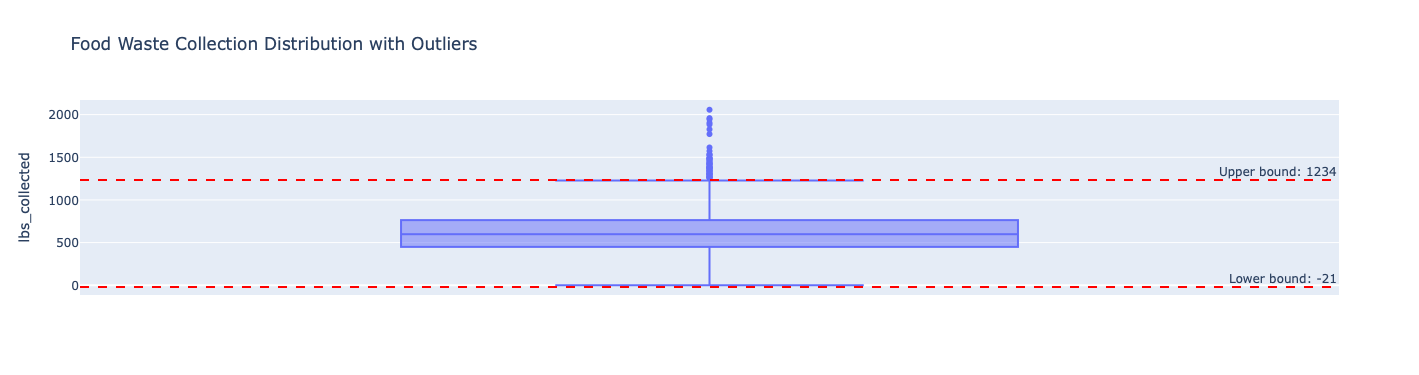

In [36]:
# Visualize outliers with box plot
fig_outliers = px.box(df_cleaner, y='lbs_collected', points='outliers',
                      title='Food Waste Collection Distribution with Outliers')
fig_outliers.add_hline(y=upper_bound, line_dash="dash", line_color="red",
                       annotation_text=f"Upper bound: {upper_bound:.0f}")
fig_outliers.add_hline(y=lower_bound, line_dash="dash", line_color="red",
                       annotation_text=f"Lower bound: {lower_bound:.0f}")
fig_outliers.show()

### Data Quality Summary

| Metric | Result |
|--------|--------|
| Total Records | 955 (after cleaning) |
| Completeness | 100% (no null values) |
| Zero Collections | X records (may need review) |
| Duplicates | X records (same site + date + lbs) |
| Compost Ratio | ~10:1 (consistent with expected formula) |
| Outliers (IQR) | X records above/below bounds |
| Date Range | Feb 2022 - Feb 2026 |
| Known Issues | Mills Park 2022 record removed |

Now that that's removed, let's look at our chart again

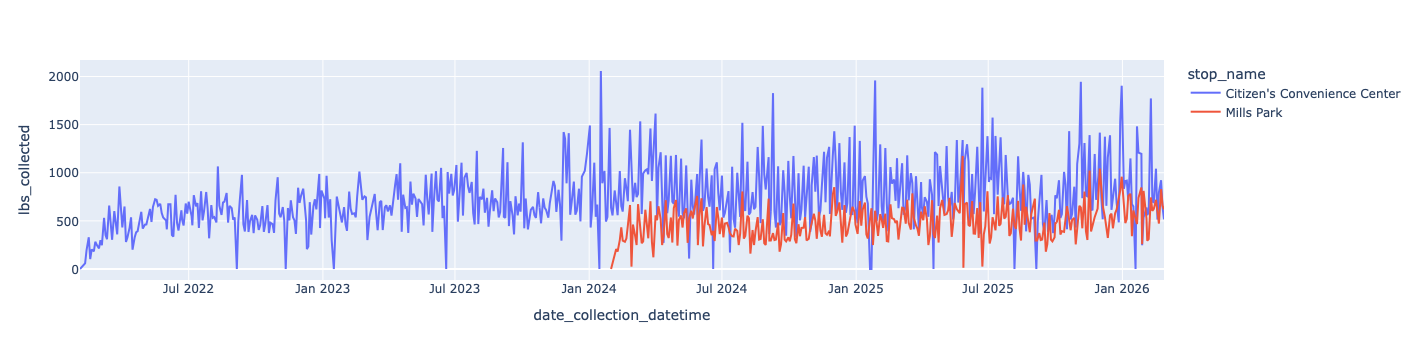

In [24]:
df_cleaner_lineplot_by_stop = px.line(df_cleaner, x='date_collection_datetime', y='lbs_collected', color='stop_name')
df_cleaner_lineplot_by_stop.show()

That's a lot better! Now, I'll proceed with using the `df_cleaner` dataframe to group the dataset by `date_collection_datetime` to get a new dataframe of daily sums of `lbs_collected`

In [25]:
#subset data frame to only include pounds collected and date_collection_datetime 
df_lbs_date = df_cleaner[['lbs_collected', 'date_collection_datetime']]
df_daily_sum = df_lbs_date.groupby(["date_collection_datetime"]).sum()
#sort this new dataframe just in case
df_daily_sum = df_daily_sum.sort_values(by='date_collection_datetime')
#reset index
df_daily_sum = df_daily_sum.reset_index()

In [26]:
df_daily_sum.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date_collection_datetime  643 non-null    datetime64[us]
 1   lbs_collected             643 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.2 KB


The above reveals that many days had more than a collection (around 300). Plotting this should look smoother:

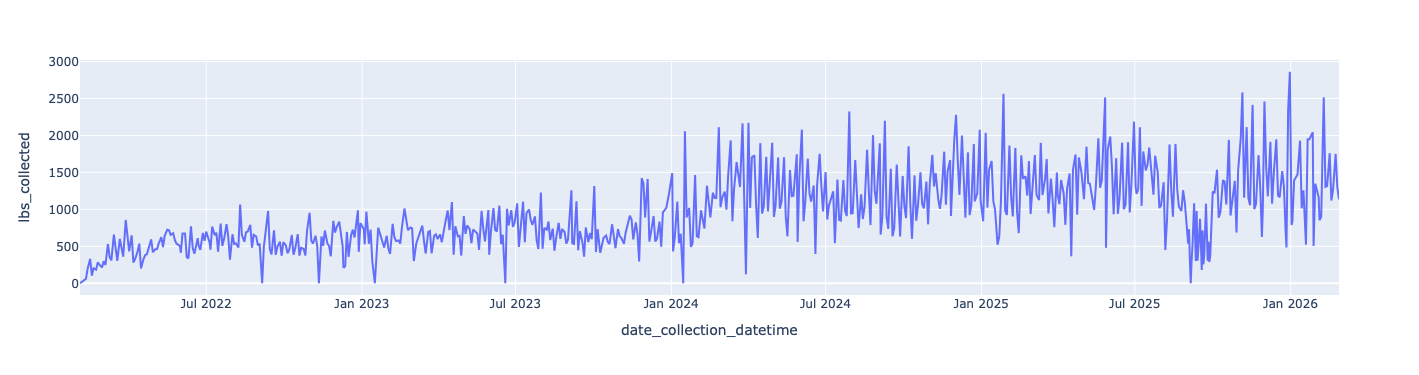

In [27]:
df_daily_lineplot = px.line(df_daily_sum, x='date_collection_datetime', y='lbs_collected')
df_daily_lineplot.show()

In [28]:
df_daily_sum.head()

,date_collection_datetime,lbs_collected
0,2022-02-02,0.0
1,2022-02-09,59.0
2,2022-02-11,197.0
3,2022-02-14,329.4
4,2022-02-16,102.8


Since the plotly library seems a lot more useful since I can hover over values and interact with charts, it seems great for creating prototypes that I can later show in my data story. I'll be redoing my statistical descriptive charts with plotly.

## Histograms of Cary Composts Data

Using the `df_cleaner` dataframe, I visualize the distribution of the data as a whole and by year

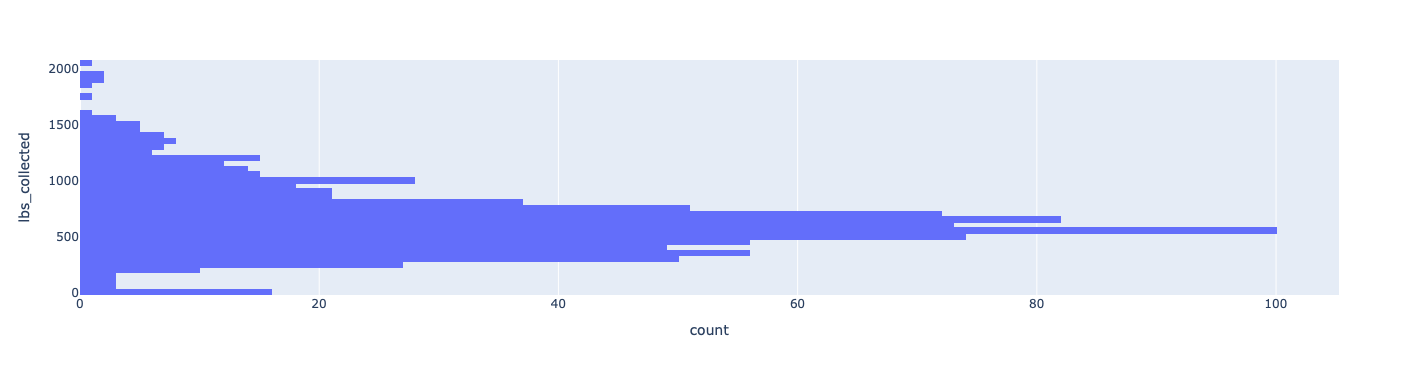

In [29]:
df_cleaner_hist_all = px.histogram(df_cleaner, y='lbs_collected')
df_cleaner_hist_all.show()

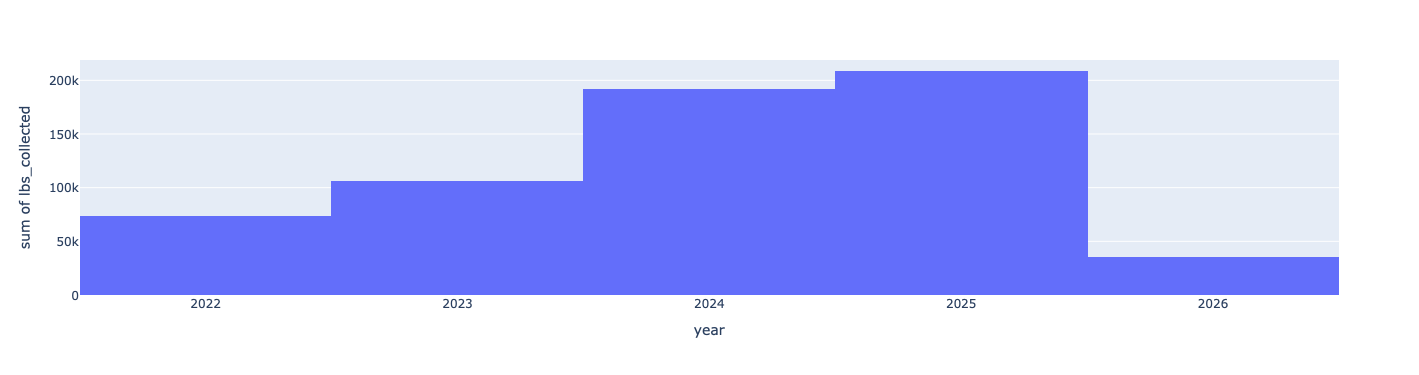

In [30]:
#histogram by year
df_cleaner_hist_year = px.histogram(df_cleaner, x='year', y='lbs_collected')
df_cleaner_hist_year.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-255' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-256' coro=<Kernel.shell_main() running at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/user/Library/CloudStorage/OneDrive-Personal/Documents/jobstuff/Continued Learning/TPG/project/venv/lib/python3.13/site-packages/_plotly_utils/utils.py:432: RuntimeWarning:

coroutine 'Kernel.shell_main' was n

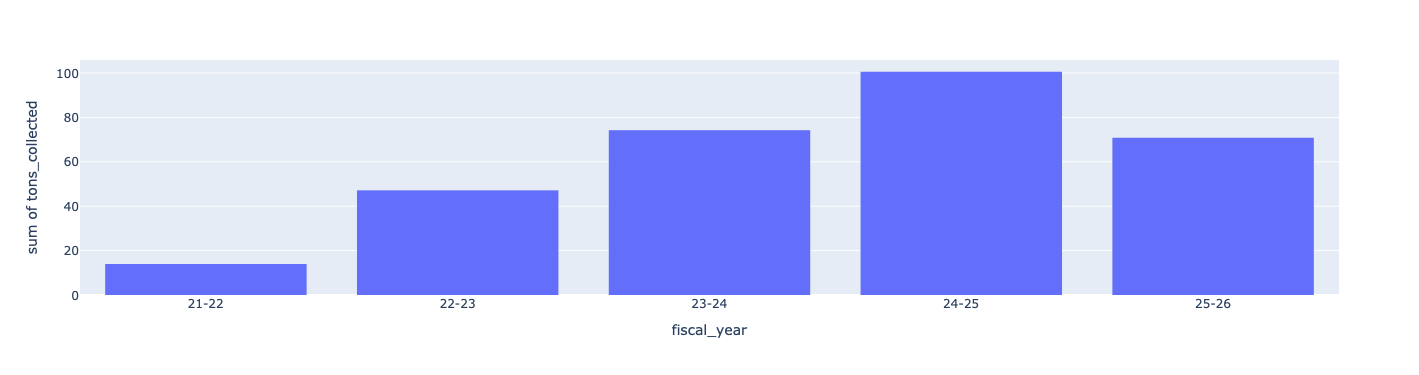

In [45]:
df_cleaner_hist_year = px.histogram(df_cleaner, x='fiscal_year', y='tons_collected')
df_cleaner_hist_year.show()

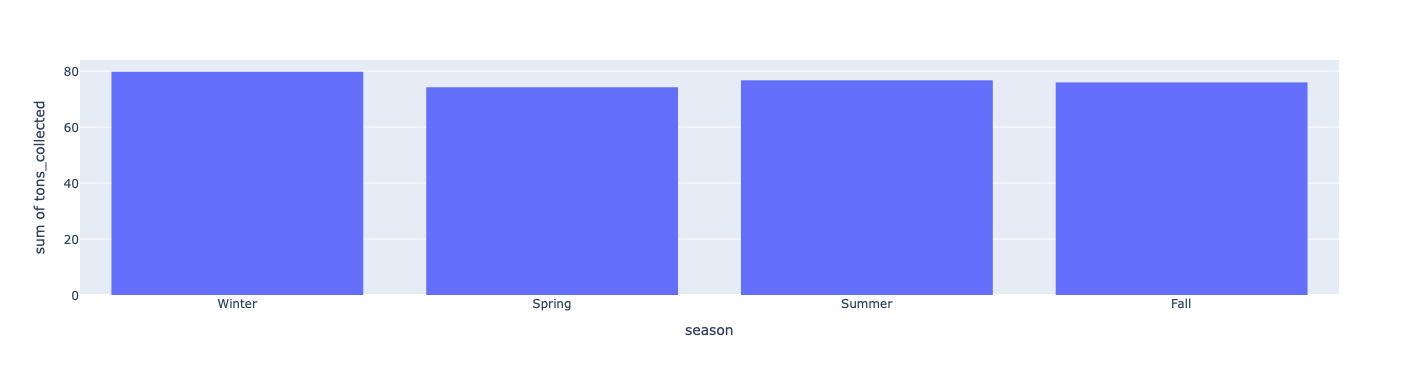

In [47]:
df_cleaner_hist_season = px.histogram(df_cleaner, x='season', y='tons_collected')
df_cleaner_hist_season.show()